In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('car_ads_details.csv')

In [3]:
df.head()

,url,Brand,Model,Kilometers,Year,Fuel Type,Transmission Type,Engine Capacity (CC),Body Type,Description,Price_EGP
0,https://www.dubizzle.com.eg/en/ad/%D9%81%D9%88...,Ford,Escort,130000,1998.0,Benzine,Manual,1300.0,Sedan,Descriptionفورد سكورت 98 مرور الاسماعيليه\n13...,"EGP 140,000"
1,https://www.dubizzle.com.eg/en/ad/%D8%B3%D8%A8...,Speranza,A113,83000,2012.0,Benzine,Manual,1300.0,Hatchback,Descriptionسياره زيرو بالكامل من المالك مباشره...,"EGP 243,000"
2,https://www.dubizzle.com.eg/en/ad/%D9%87%D9%88...,Honda,City,100000,2008.0,Benzine,Automatic,1500.0,Sedan,Descriptionسيارة هوندا سيتي موديل 2008 راشه با...,"EGP 240,000"
3,https://www.dubizzle.com.eg/en/ad/%D9%81%D9%88...,Volkswagen,Pointer,180000,2006.0,Benzine,Manual,1600.0,Hatchback,Descriptionعربيه فولكس بونتير موديل ٢٠٠٦ مرور ...,"EGP 155,000"
4,https://www.dubizzle.com.eg/en/ad/geely-emgran...,Geely,Emgrand 7,215000,2017.0,Diesel,Manual,1600.0,Sedan,Descriptionسيارة فبريكا بالكامل دواخل بحالة فو...,"EGP 380,000"


In [4]:
# we will now clean the data set
# we will do the important steps of data cleaning like
# 1. handling rows with missing target values and remove unrealistic prices
# 2. handling duplicates
# 3. handling inconsistent data types
# 4. handling outlier
# 5. extracting keywords from description column
# 6. removing irrelevant columns

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8519 entries, 0 to 8518
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   url                   8519 non-null   object 
 1   Brand                 8446 non-null   object 
 2   Model                 8390 non-null   object 
 3   Kilometers            8447 non-null   object 
 4   Year                  8448 non-null   float64
 5   Fuel Type             8448 non-null   object 
 6   Transmission Type     8448 non-null   object 
 7   Engine Capacity (CC)  6460 non-null   float64
 8   Body Type             7888 non-null   object 
 9   Description           8448 non-null   object 
 10  Price_EGP             8448 non-null   object 
dtypes: float64(2), object(9)
memory usage: 732.2+ KB


In [6]:
df.isnull().sum()

url                        0
Brand                     73
Model                    129
Kilometers                72
Year                      71
Fuel Type                 71
Transmission Type         71
Engine Capacity (CC)    2059
Body Type                631
Description               71
Price_EGP                 71
dtype: int64

In [7]:
df[(df['Price_EGP']=='EGP 0') | (df["Price_EGP"].isna())]

,url,Brand,Model,Kilometers,Year,Fuel Type,Transmission Type,Engine Capacity (CC),Body Type,Description,Price_EGP
41,https://www.dubizzle.com.eg/en/ad/%D8%AA%D9%88...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
156,https://www.dubizzle.com.eg/en/ad/%D8%B3%D9%8A...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
302,https://www.dubizzle.com.eg/en/ad/chevrolet-op...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
348,https://www.dubizzle.com.eg/en/ad/%D8%AC%D9%8A...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
373,https://www.dubizzle.com.eg/en/ad/toyota-corol...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
7997,https://www.dubizzle.com.eg/en/ad/%D8%AA%D9%88...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8101,https://www.dubizzle.com.eg/en/ad/%D8%B3%D8%A8...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8303,https://www.dubizzle.com.eg/en/ad/hyundai-viva...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8387,https://www.dubizzle.com.eg/en/ad/lada-2107-20...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
# we have 71 rows with missing or zero price in our target column Price_EGP
# we will remove these rows from our data set we dont fill them artficially because price is our target variable

df=df[~(df["Price_EGP"].isna() | (df['Price_EGP']=='EGP 0'))]

In [9]:
df.isnull().sum()

url                        0
Brand                      2
Model                     58
Kilometers                 1
Year                       0
Fuel Type                  0
Transmission Type          0
Engine Capacity (CC)    1988
Body Type                560
Description                0
Price_EGP                  0
dtype: int64

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8448 entries, 0 to 8518
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   url                   8448 non-null   object 
 1   Brand                 8446 non-null   object 
 2   Model                 8390 non-null   object 
 3   Kilometers            8447 non-null   object 
 4   Year                  8448 non-null   float64
 5   Fuel Type             8448 non-null   object 
 6   Transmission Type     8448 non-null   object 
 7   Engine Capacity (CC)  6460 non-null   float64
 8   Body Type             7888 non-null   object 
 9   Description           8448 non-null   object 
 10  Price_EGP             8448 non-null   object 
dtypes: float64(2), object(9)
memory usage: 792.0+ KB


In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.drop('url', axis=1).duplicated().sum()
# we have 30 duplicate rows we will remove them

np.int64(30)

In [13]:
duplicates = df[df.drop('url', axis=1).duplicated(keep=False)].sort_values(by="Year")
duplicates

,url,Brand,Model,Kilometers,Year,Fuel Type,Transmission Type,Engine Capacity (CC),Body Type,Description,Price_EGP
4638,https://www.dubizzle.com.eg/en/ad/%D9%85%D8%A7...,Mazda,323,160,1982.0,Benzine,Manual,1300.0,4X4,Descriptionمازدا 323 موديل 82 موتور 1300 سي سي...,"EGP 80,000"
6420,https://www.dubizzle.com.eg/en/ad/%D9%85%D8%A7...,Mazda,323,160,1982.0,Benzine,Manual,1300.0,4X4,Descriptionمازدا 323 موديل 82 موتور 1300 سي سي...,"EGP 80,000"
5335,https://www.dubizzle.com.eg/en/ad/%D8%AA%D9%88...,Toyota,Yaris,345000,2007.0,Benzine,Manual,1300.0,Sedan,Descriptionتويوتا ياريس موديل 2007 مانيوال رشه...,"EGP 340,000"
957,https://www.dubizzle.com.eg/en/ad/ford-focus-2...,Ford,Focus,290000,2007.0,Benzine,Automatic,1600.0,Sedan,Descriptionفورد فوكس ٢٠٠٧ اوتوماتيك. \nفبريكة ...,"EGP 370,000"
5718,https://www.dubizzle.com.eg/en/ad/%D8%AA%D9%88...,Toyota,Yaris,345000,2007.0,Benzine,Manual,1300.0,Sedan,Descriptionتويوتا ياريس موديل 2007 مانيوال رشه...,"EGP 340,000"
6201,https://www.dubizzle.com.eg/en/ad/ford-focus-2...,Ford,Focus,290000,2007.0,Benzine,Automatic,1600.0,Sedan,Descriptionفورد فوكس ٢٠٠٧ اوتوماتيك. \nفبريكة ...,"EGP 370,000"
3301,https://www.dubizzle.com.eg/en/ad/%D9%85%D8%A7...,Mazda,3,329000,2008.0,Benzine,Automatic,1600.0,Sedan,Descriptionمازدا 3 للبيع ٢٠٠٨\n\nحالة ممتازه ب...,"EGP 360,000"
3121,https://www.dubizzle.com.eg/en/ad/%D8%B4%D9%8A...,Chevrolet,Spark,180000,2008.0,Benzine,Manual,1000.0,Hatchback,Descriptionسيارة شيفروليه سبارك 2008 هي سيارة ...,"EGP 200,000"
6821,https://www.dubizzle.com.eg/en/ad/%D9%85%D8%A7...,Mazda,3,329000,2008.0,Benzine,Automatic,1600.0,Sedan,Descriptionمازدا 3 للبيع ٢٠٠٨\n\nحالة ممتازه ب...,"EGP 360,000"
4268,https://www.dubizzle.com.eg/en/ad/%D8%B4%D9%8A...,Chevrolet,Spark,180000,2008.0,Benzine,Manual,1000.0,Hatchback,Descriptionسيارة شيفروليه سبارك 2008 هي سيارة ...,"EGP 200,000"


In [14]:
df.drop_duplicates(subset=df.columns.difference(['url']), inplace=True)

In [15]:
df.dtypes

url                      object
Brand                    object
Model                    object
Kilometers               object
Year                    float64
Fuel Type                object
Transmission Type        object
Engine Capacity (CC)    float64
Body Type                object
Description              object
Price_EGP                object
dtype: object

In [16]:
df.head()

,url,Brand,Model,Kilometers,Year,Fuel Type,Transmission Type,Engine Capacity (CC),Body Type,Description,Price_EGP
0,https://www.dubizzle.com.eg/en/ad/%D9%81%D9%88...,Ford,Escort,130000,1998.0,Benzine,Manual,1300.0,Sedan,Descriptionفورد سكورت 98 مرور الاسماعيليه\n13...,"EGP 140,000"
1,https://www.dubizzle.com.eg/en/ad/%D8%B3%D8%A8...,Speranza,A113,83000,2012.0,Benzine,Manual,1300.0,Hatchback,Descriptionسياره زيرو بالكامل من المالك مباشره...,"EGP 243,000"
2,https://www.dubizzle.com.eg/en/ad/%D9%87%D9%88...,Honda,City,100000,2008.0,Benzine,Automatic,1500.0,Sedan,Descriptionسيارة هوندا سيتي موديل 2008 راشه با...,"EGP 240,000"
3,https://www.dubizzle.com.eg/en/ad/%D9%81%D9%88...,Volkswagen,Pointer,180000,2006.0,Benzine,Manual,1600.0,Hatchback,Descriptionعربيه فولكس بونتير موديل ٢٠٠٦ مرور ...,"EGP 155,000"
4,https://www.dubizzle.com.eg/en/ad/geely-emgran...,Geely,Emgrand 7,215000,2017.0,Diesel,Manual,1600.0,Sedan,Descriptionسيارة فبريكا بالكامل دواخل بحالة فو...,"EGP 380,000"


In [17]:
df['Price_EGP'] = df['Price_EGP'].str.replace('EGP ', '').str.replace(',', '').astype(float)
df['Year'] = df['Year'].astype(int)
df['Kilometers'] = pd.to_numeric(df['Kilometers'], errors='coerce').astype('Int64')
df['Engine Capacity (CC)'] = df['Engine Capacity (CC)'].astype('Int64')

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8418 entries, 0 to 8518
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   url                   8418 non-null   object 
 1   Brand                 8416 non-null   object 
 2   Model                 8360 non-null   object 
 3   Kilometers            8415 non-null   Int64  
 4   Year                  8418 non-null   int64  
 5   Fuel Type             8418 non-null   object 
 6   Transmission Type     8418 non-null   object 
 7   Engine Capacity (CC)  6434 non-null   Int64  
 8   Body Type             7858 non-null   object 
 9   Description           8418 non-null   object 
 10  Price_EGP             8418 non-null   float64
dtypes: Int64(2), float64(1), int64(1), object(7)
memory usage: 805.6+ KB


In [19]:
df.head()

,url,Brand,Model,Kilometers,Year,Fuel Type,Transmission Type,Engine Capacity (CC),Body Type,Description,Price_EGP
0,https://www.dubizzle.com.eg/en/ad/%D9%81%D9%88...,Ford,Escort,130000,1998,Benzine,Manual,1300,Sedan,Descriptionفورد سكورت 98 مرور الاسماعيليه\n13...,140000.0
1,https://www.dubizzle.com.eg/en/ad/%D8%B3%D8%A8...,Speranza,A113,83000,2012,Benzine,Manual,1300,Hatchback,Descriptionسياره زيرو بالكامل من المالك مباشره...,243000.0
2,https://www.dubizzle.com.eg/en/ad/%D9%87%D9%88...,Honda,City,100000,2008,Benzine,Automatic,1500,Sedan,Descriptionسيارة هوندا سيتي موديل 2008 راشه با...,240000.0
3,https://www.dubizzle.com.eg/en/ad/%D9%81%D9%88...,Volkswagen,Pointer,180000,2006,Benzine,Manual,1600,Hatchback,Descriptionعربيه فولكس بونتير موديل ٢٠٠٦ مرور ...,155000.0
4,https://www.dubizzle.com.eg/en/ad/geely-emgran...,Geely,Emgrand 7,215000,2017,Diesel,Manual,1600,Sedan,Descriptionسيارة فبريكا بالكامل دواخل بحالة فو...,380000.0


In [20]:
pd.set_option('display.float_format', lambda x: '%.0f' % x)
df.describe()

,Kilometers,Year,Engine Capacity (CC),Price_EGP
count,8415,8418,6434,8418
mean,144610,2012,1742,1156859
std,131941,11,753,1778315
min,1,1900,100,1100
25%,52000,2006,1500,260000
50%,126000,2015,1600,550000
75%,200000,2021,1600,1300000
max,3000000,2026,10000,25000000


In [21]:
# now we remove outliers from numeric columns using IQR method

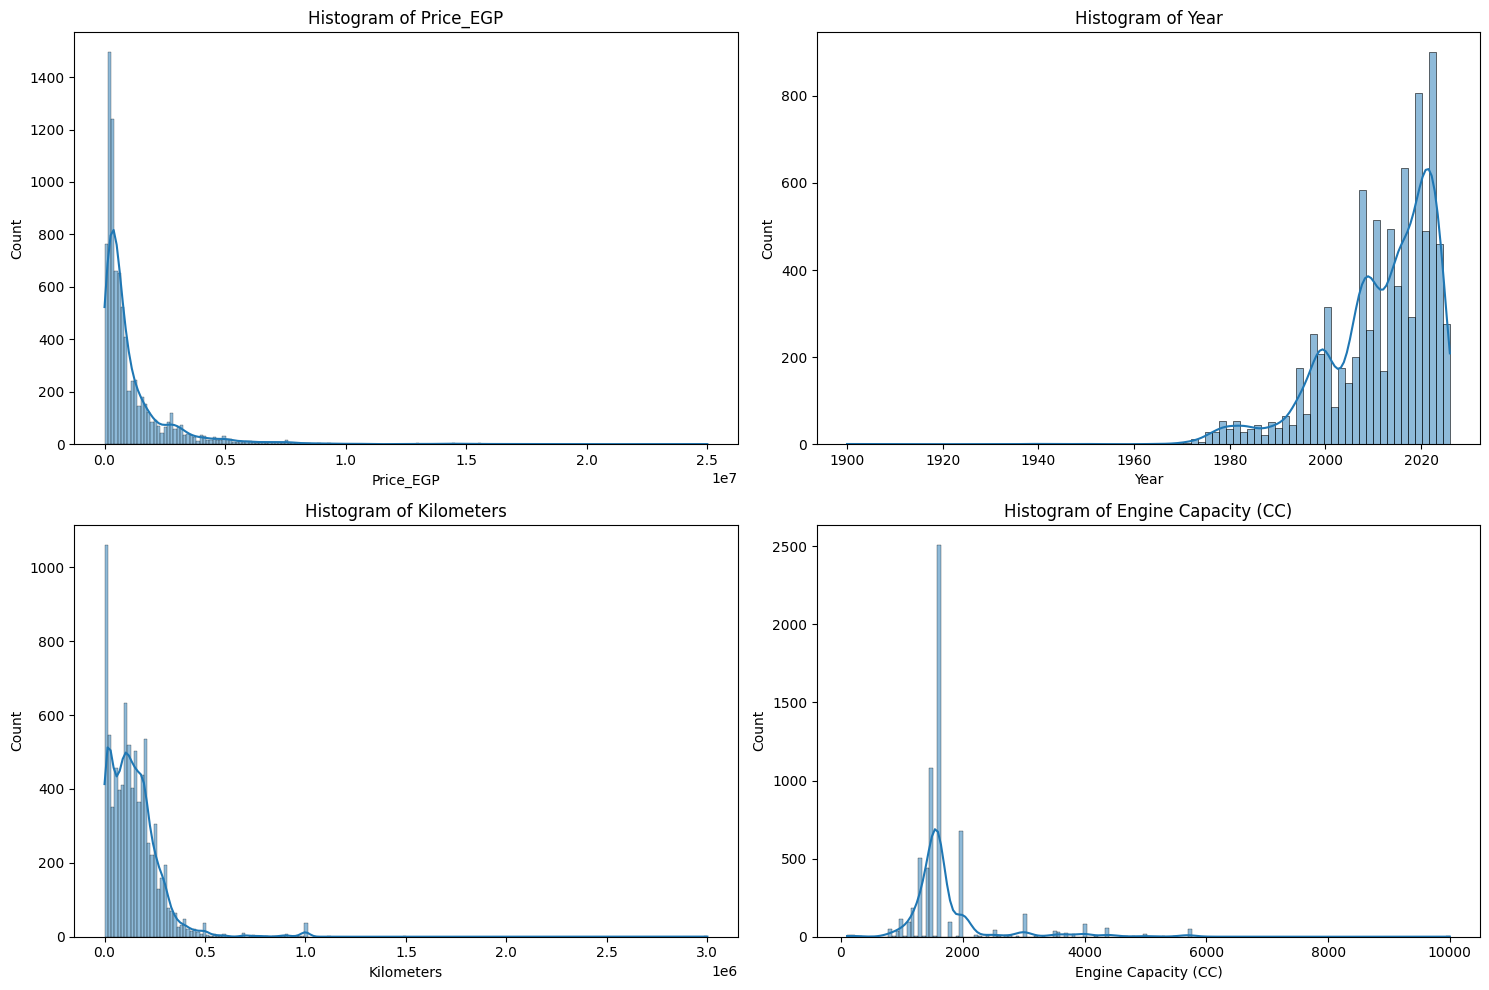

In [22]:
hist_plots = ['Price_EGP', 'Year', 'Kilometers', 'Engine Capacity (CC)']
plt.figure(figsize=(15, 10))
for i, column in enumerate(hist_plots, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[column], kde=True)
    plt.title(f'Histogram of {column}')
plt.tight_layout()
plt.show()  

In [23]:
# we our data is skewed its expected in car data sets as there are cars with high prices and high mileage old cars etc
# so instead of removing outliers using IQR as we ill remove thousands of data points this way we will detect invalid outliers (errors) NOT natural ones


In [24]:
# first we will start with price column
df[df['Price_EGP']==1100]

,url,Brand,Model,Kilometers,Year,Fuel Type,Transmission Type,Engine Capacity (CC),Body Type,Description,Price_EGP
5548,https://www.dubizzle.com.eg/en/ad/%D9%86%D9%8A...,Nissan,Sunny,80000,2022,Benzine,Automatic,<NA>,NaN,Descriptionسياره نيسان صني 2022\nللايجار وا...,1100


In [25]:
df[df['Price_EGP']==25000000]

,url,Brand,Model,Kilometers,Year,Fuel Type,Transmission Type,Engine Capacity (CC),Body Type,Description,Price_EGP
5688,https://www.dubizzle.com.eg/en/ad/%D8%B3%D9%83...,Skoda,Kodiaq,300,2024,Benzine,Automatic,1500,SUV,Descriptionموديل 2024 الشيب الجديد selection s...,25000000


In [26]:
# we will set a reasonable range for car prices in Egypt
df = df[(df['Price_EGP'] >= 100000) & (df['Price_EGP'] <= 7000000)]

In [27]:
df[df['Year'] == 1900]

,url,Brand,Model,Kilometers,Year,Fuel Type,Transmission Type,Engine Capacity (CC),Body Type,Description,Price_EGP


In [28]:
# year column we will set a reasonable range from 1980 to 2026
df = df[(df['Year'] >= 1980) & (df['Year'] <= 2026)]

In [29]:
df[df['Engine Capacity (CC)'] == 100]

,url,Brand,Model,Kilometers,Year,Fuel Type,Transmission Type,Engine Capacity (CC),Body Type,Description,Price_EGP
3289,https://www.dubizzle.com.eg/en/ad/volkswagen-i...,Volkswagen,ID6,12000,2022,Electric,Automatic,100,SUV,Descriptionid6 pro 2022\n32000 km\noriginal pa...,1640000
3874,https://www.dubizzle.com.eg/en/ad/%D8%B3%D9%83...,Skoda,Felecia,100000,1995,Benzine,Manual,100,Hatchback,Descriptionرخصة سنة\nانتهاء ٣٠_٨_٢٠٢٦\nفحص ٢٠٢...,125000
5346,https://www.dubizzle.com.eg/en/ad/bmw-ix-xdriv...,BMW,IX,2800,2023,Electric,Automatic,100,SUV,Descriptionono of one in Egypt \nBMW IX - xDri...,2300000
6432,https://www.dubizzle.com.eg/en/ad/%D8%A7%D9%81...,Avatr,12,8000,2024,Electric,Automatic,100,Sedan,Descriptionافتار 12 اول مالك 2024\nفابريكا بال...,2800000
7018,https://www.dubizzle.com.eg/en/ad/mercedes-ben...,Mercedes-Benz,EQE 350,26000,2024,Electric,Automatic,100,SUV,Descriptionبحاله الزيرو اعلي مواصفات سماعات بر...,2975000


In [30]:
df[df['Engine Capacity (CC)'] == 10000]

,url,Brand,Model,Kilometers,Year,Fuel Type,Transmission Type,Engine Capacity (CC),Body Type,Description,Price_EGP
1527,https://www.dubizzle.com.eg/en/ad/%D9%87%D9%8A...,Hyundai,Verna,140000,2015,Benzine,Automatic,10000,Sedan,Descriptionسياره ازاز فاميه اتوماتك طقم چنط سبور,385000


In [31]:
# engine capacity column we will set a reasonable range from 1000 CC to 5000 CC
df = df[((df['Engine Capacity (CC)'] >= 1000) & (df['Engine Capacity (CC)'] <= 5000))]


In [32]:
df[df['Kilometers'] == 1]

,url,Brand,Model,Kilometers,Year,Fuel Type,Transmission Type,Engine Capacity (CC),Body Type,Description,Price_EGP
10,https://www.dubizzle.com.eg/en/ad/%D8%A3%D9%88...,Opel,Vectra,1,1998,Benzine,Manual,1600,Sedan,Descriptionفبريكا دواخل تكيف يعمل مش محتاجه م...,230000
388,https://www.dubizzle.com.eg/en/ad/hyundai-acce...,Hyundai,Accent,1,1999,Benzine,Manual,1500,Sedan,Descriptionهيونداي اكسنت موديل 1999\nرشه بره ب...,225000
766,https://www.dubizzle.com.eg/en/ad/skoda-feleci...,Skoda,Felecia,1,1997,Benzine,Manual,1300,Hatchback,Descriptionسكودا فليشيا موديل ٩٧ \nزجاج امامي ...,145000
795,https://www.dubizzle.com.eg/en/ad/%D8%AC%D9%8A...,Jeep,Cherokee,1,1994,Benzine,Manual,2500,4X4,Descriptionجيب شروكي 1994ماتوراصلي جلد بلكامل ...,180000
1062,https://www.dubizzle.com.eg/en/ad/%D9%87%D9%8A...,Hyundai,Other,1,2002,Benzine,Automatic,1500,Hatchback,Descriptionهيونداي لافيتا2002 اتوماتيك لون دهب...,345000
1141,https://www.dubizzle.com.eg/en/ad/%D9%83%D9%8A...,Kia,Pride,1,1998,Benzine,Manual,1300,Sedan,Descriptionللبيع - كيا برايد سيدان 1998 \n فاب...,120000
1143,https://www.dubizzle.com.eg/en/ad/%D8%B3%D9%8A...,Seat,Cordoba,1,2001,Natural Gas,Manual,1600,Sedan,Descriptionسيات كوردوبا ٢٠٠١\nمانيوال\nبنزين و...,180000
1818,https://www.dubizzle.com.eg/en/ad/%D8%AF%D9%88...,Fiat,Shahin,1,2006,Benzine,Manual,1400,Sedan,Descriptionعربية شاهين دوجان 2006فبريكة دواخل ...,120000
2202,https://www.dubizzle.com.eg/en/ad/%D9%81%D9%8A...,Fiat,Uno,1,2009,Diesel,Manual,1600,Hatchback,Descriptionفيات اونو \nرخصة سنتين ونص دمياط رش...,140000
2408,https://www.dubizzle.com.eg/en/ad/%D9%81%D9%8A...,Fiat,Siena,1,2001,Benzine,Manual,1600,Sedan,Descriptionسيارة فيات سيينا موديل 2001 ماتور 1...,110000


In [33]:
df[df['Kilometers'] == 3000000]

,url,Brand,Model,Kilometers,Year,Fuel Type,Transmission Type,Engine Capacity (CC),Body Type,Description,Price_EGP


In [34]:
# millage column we will set a reasonable range 
df = df[((df['Kilometers'] >= 0) & (df['Kilometers'] <= 500000))]


In [35]:
df[df['Kilometers'].isin([0, 1])]

,url,Brand,Model,Kilometers,Year,Fuel Type,Transmission Type,Engine Capacity (CC),Body Type,Description,Price_EGP
10,https://www.dubizzle.com.eg/en/ad/%D8%A3%D9%88...,Opel,Vectra,1,1998,Benzine,Manual,1600,Sedan,Descriptionفبريكا دواخل تكيف يعمل مش محتاجه م...,230000
388,https://www.dubizzle.com.eg/en/ad/hyundai-acce...,Hyundai,Accent,1,1999,Benzine,Manual,1500,Sedan,Descriptionهيونداي اكسنت موديل 1999\nرشه بره ب...,225000
766,https://www.dubizzle.com.eg/en/ad/skoda-feleci...,Skoda,Felecia,1,1997,Benzine,Manual,1300,Hatchback,Descriptionسكودا فليشيا موديل ٩٧ \nزجاج امامي ...,145000
795,https://www.dubizzle.com.eg/en/ad/%D8%AC%D9%8A...,Jeep,Cherokee,1,1994,Benzine,Manual,2500,4X4,Descriptionجيب شروكي 1994ماتوراصلي جلد بلكامل ...,180000
1062,https://www.dubizzle.com.eg/en/ad/%D9%87%D9%8A...,Hyundai,Other,1,2002,Benzine,Automatic,1500,Hatchback,Descriptionهيونداي لافيتا2002 اتوماتيك لون دهب...,345000
1141,https://www.dubizzle.com.eg/en/ad/%D9%83%D9%8A...,Kia,Pride,1,1998,Benzine,Manual,1300,Sedan,Descriptionللبيع - كيا برايد سيدان 1998 \n فاب...,120000
1143,https://www.dubizzle.com.eg/en/ad/%D8%B3%D9%8A...,Seat,Cordoba,1,2001,Natural Gas,Manual,1600,Sedan,Descriptionسيات كوردوبا ٢٠٠١\nمانيوال\nبنزين و...,180000
1818,https://www.dubizzle.com.eg/en/ad/%D8%AF%D9%88...,Fiat,Shahin,1,2006,Benzine,Manual,1400,Sedan,Descriptionعربية شاهين دوجان 2006فبريكة دواخل ...,120000
2202,https://www.dubizzle.com.eg/en/ad/%D9%81%D9%8A...,Fiat,Uno,1,2009,Diesel,Manual,1600,Hatchback,Descriptionفيات اونو \nرخصة سنتين ونص دمياط رش...,140000
2408,https://www.dubizzle.com.eg/en/ad/%D9%81%D9%8A...,Fiat,Siena,1,2001,Benzine,Manual,1600,Sedan,Descriptionسيارة فيات سيينا موديل 2001 ماتور 1...,110000


In [36]:
# after checking we will remove rows where Kilometers is 1 or 0 for non current year cars or new cars
df = df[~((df['Kilometers'] == 1) & (~df['Year'].isin([2025, 2026])))]

In [37]:
df[df['Kilometers'].isin([0, 1])]

,url,Brand,Model,Kilometers,Year,Fuel Type,Transmission Type,Engine Capacity (CC),Body Type,Description,Price_EGP
3184,https://www.dubizzle.com.eg/en/ad/%D8%B3%D9%83...,Skoda,Kodiaq,1,2025,Benzine,Automatic,1500,SUV,Descriptionسكودا كودياك سيلكشن بلاس \nالشكل ال...,2600000
4077,https://www.dubizzle.com.eg/en/ad/skoda-kodiaq...,Skoda,Kodiaq,1,2026,Benzine,Automatic,1400,SUV,Descriptionسكودا كودياك اعلى فئة 2025\nشرقاوي ...,3100000
6265,https://www.dubizzle.com.eg/en/ad/koda-octavia...,Skoda,Octavia,1,2026,Benzine,Automatic,1400,Sedan,DescriptionŠkoda Octavia Lounge 2026\nشرقاوي أ...,1850000
7396,https://www.dubizzle.com.eg/en/ad/audi-a5-s-li...,Audi,A5,1,2025,Benzine,Automatic,2000,Sedan,DescriptionAudi A5 S-Line 2025\nشرقاوي أوتو مو...,3800000


In [38]:
df["Kilometers"].replace({1:0}, inplace=True)

C:\Users\alyah\AppData\Local\Temp\ipykernel_10552\1905972071.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Kilometers"].replace({1:0}, inplace=True)


In [39]:
df.describe()

,Kilometers,Year,Engine Capacity (CC),Price_EGP
count,5719,5719,5719,5719
mean,142640,2013,1699,1043343
std,98861,9,548,1173499
min,0,1980,1000,100000
25%,63000,2008,1500,307500
50%,135000,2015,1600,600000
75%,200000,2020,1600,1257500
max,500000,2026,5000,7000000


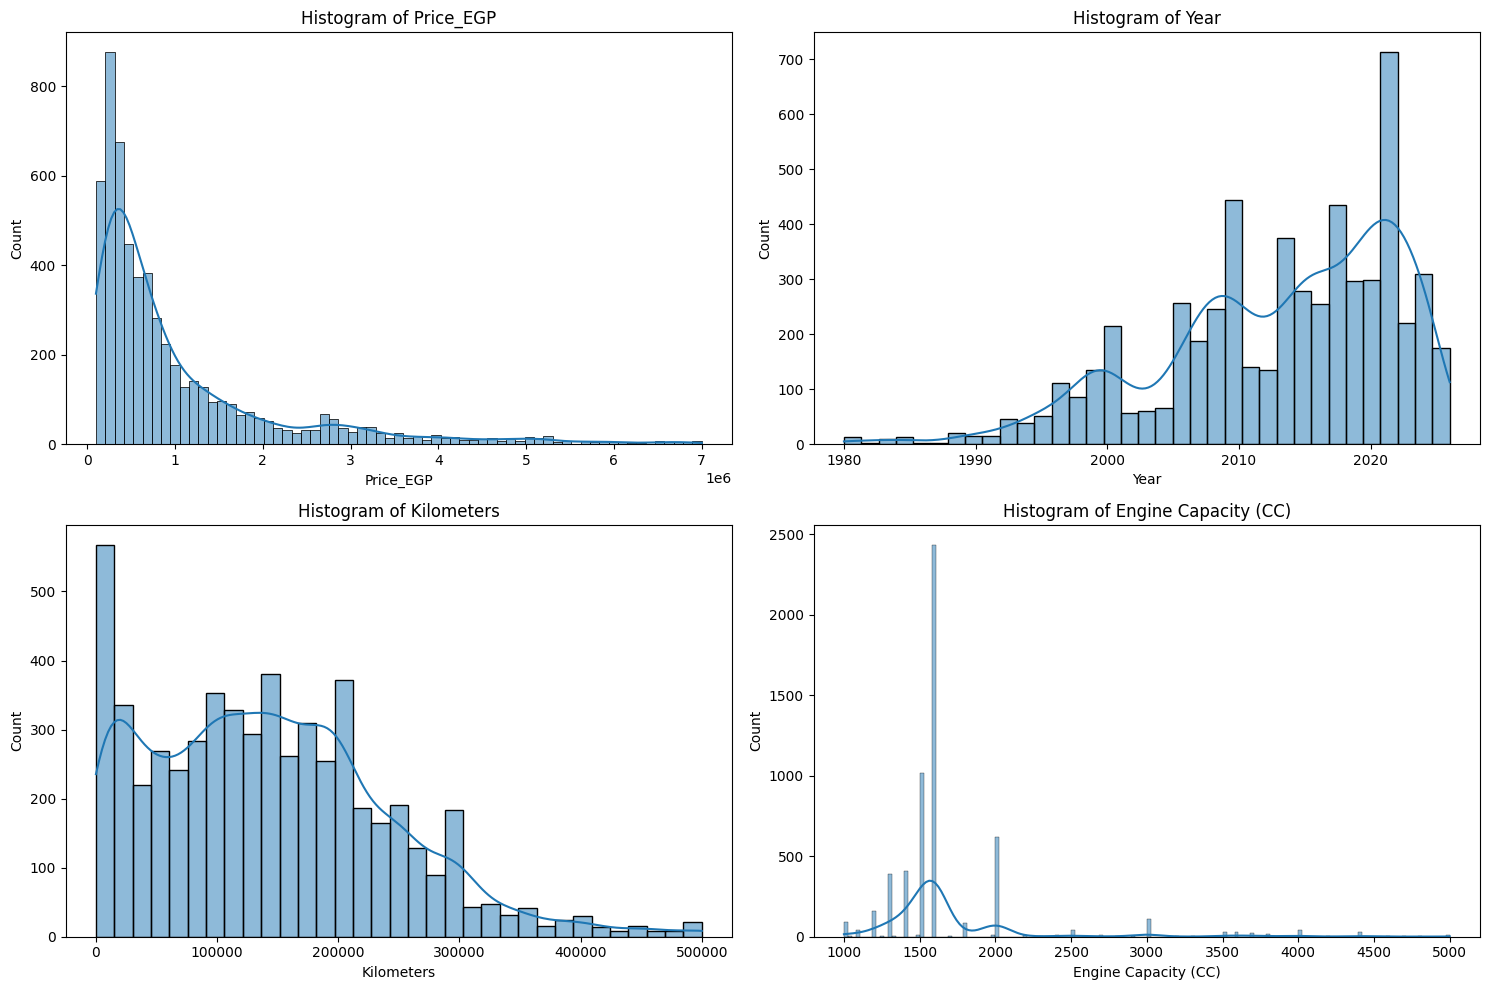

In [40]:
hist_plots = ['Price_EGP', 'Year', 'Kilometers', 'Engine Capacity (CC)']
plt.figure(figsize=(15, 10))
for i, column in enumerate(hist_plots, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[column], kde=True)
    plt.title(f'Histogram of {column}')
plt.tight_layout()
plt.show()  

In [41]:
# we will extract keywords from description column
df['Description'].head()

0    Descriptionفورد سكورت 98  مرور الاسماعيليه\n13...
1    Descriptionسياره زيرو بالكامل من المالك مباشره...
2    Descriptionسيارة هوندا سيتي موديل 2008 راشه با...
3    Descriptionعربيه فولكس بونتير موديل ٢٠٠٦ مرور ...
4    Descriptionسيارة فبريكا بالكامل دواخل بحالة فو...
Name: Description, dtype: object

In [42]:
# Condition
df["fabrika"] = df["Description"].str.contains(
    r"فبريكا|فابريكة|فابريكا|فبريكة|فبريكه|fabrika", regex=True).astype(int)

df["zero_condition"] = df["Description"].str.contains(
    r"زيرو|زيروو|zero", regex=True, case=False).astype(int)

df["rasha"] = df["Description"].str.contains(
    r"رشة|رش|راشه(?!ة كاملة)", regex=True).astype(int)

df["accident"] = df["Description"].str.contains(
    r"حادث|حادثة|خبط|خبطة|accident", regex=True, case=False).astype(int)

df["excellent_condition"] = df["Description"].str.contains(
    r"حالة ممتازة|كونديشن ممتازة|كونديشن ممتاز|excellent condition|حاله ممتازه|حاله ممتازة",
    regex=True, case=False
).astype(int)

# repairs/maintenance
df["service_center"] = df["Description"].str.contains(
    r"صيانات? توكيل|صيانة توكيل", regex=True).astype(int)

df["full_service_history"] = df["Description"].str.contains(
    r"سجل صيانة كامل|صيانة منتظمة|صيانة كاملة", regex=True).astype(int)

df["major_repairs"] = df["Description"].str.contains(
    r"تغيير موتور|تغيير فتيس|تغيير محرك|قطع غيار جديدة", regex=True).astype(int)

# Features
df["sunroof"] = df["Description"].str.contains(
    r"فتحة سقف|sunroof", regex=True, case=False).astype(int)

df["leather"] = df["Description"].str.contains(
    r"فرش جلد|جلد", regex=True).astype(int)

df["screen"] = df["Description"].str.contains(
    r"شاشة|نافيجيشن|screen|navigation", regex=True, case=False).astype(int)

df["sensors"] = df["Description"].str.contains(
    r"حساسات|حساس|parking sensor", regex=True, case=False).astype(int)

df["rear_camera"] = df["Description"].str.contains(
    r"كاميرا خلف(ية)?|back camera", regex=True, case=False).astype(int)

df["cruise"] = df["Description"].str.contains(
    r"مثبت سرعة|cruise control", regex=True, case=False).astype(int)

df["alloy"] = df["Description"].str.contains(
    r"جنط سبور|جنوط سبور|alloy", regex=True).astype(int)

df["push_start"] = df["Description"].str.contains(
    r"بصمة|push start|start button", regex=True, case=False).astype(int)

df["abs"] = df["Description"].str.contains(
    r"فرامل abs|abs", regex=True, case=False).astype(int)

df["airbags"] = df["Description"].str.contains(
    r"ايرباج|ايرباجات|airbag", regex=True, case=False).astype(int)

df["air_condition"] = df["Description"].str.contains(
    r"تكييف|مكيف|تكييف تاتش|تكييف اوتوماتيك|air condition|ac", regex=True, case=False).astype(int)

df["electric_windows"] = df["Description"].str.contains(
    r"زجاج كهربا|زجاج كهربائي|electric window", regex=True, case=False).astype(int)

df["electric_mirrors"] = df["Description"].str.contains(
    r"مرايات كهربا|مرايا كهربا|مرايات كهربائية|electric mirror", regex=True, case=False).astype(int)

df["bluetooth"] = df["Description"].str.contains(
    r"بلوتوث|bluetooth", regex=True, case=False).astype(int)

df["fog_lights"] = df["Description"].str.contains(
    r"كشافات|فوج لايت|fog light", regex=True, case=False).astype(int)

df["remote_key"] = df["Description"].str.contains(
    r"ريموت|مفتاح ريموت|remote key", regex=True, case=False).astype(int)

df["two_keys"] = df["Description"].str.contains(
    r"مفتاحين|2 مفتاح|two keys", regex=True, case=False).astype(int)

df["full_option"] = df["Description"].str.contains(
    r"كاملة|فول اوبشن|full option", regex=True, case=False).astype(int)

# Usage
df["first_owner"] = df["Description"].str.contains(
    r"مالك أول|أول يد|اول يد|first owner", regex=True, case=False).astype(int)

df["family_use"] = df["Description"].str.contains(
    r"استخدام عائلي|استعمال عائلي", regex=True).astype(int)

df["commercial_use"] = df["Description"].str.contains(
    r"أوبر|تاكسي|uber|taxi", regex=True, case=False).astype(int)

df["light_use"] = df["Description"].str.contains(
    r"استعمال خفيف|استعمال بسيط", regex=True).astype(int)



C:\Users\alyah\AppData\Local\Temp\ipykernel_10552\3771142423.py:42: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df["rear_camera"] = df["Description"].str.contains(


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5719 entries, 0 to 8517
Data columns (total 41 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   url                   5719 non-null   object 
 1   Brand                 5719 non-null   object 
 2   Model                 5719 non-null   object 
 3   Kilometers            5719 non-null   Int64  
 4   Year                  5719 non-null   int64  
 5   Fuel Type             5719 non-null   object 
 6   Transmission Type     5719 non-null   object 
 7   Engine Capacity (CC)  5719 non-null   Int64  
 8   Body Type             5719 non-null   object 
 9   Description           5719 non-null   object 
 10  Price_EGP             5719 non-null   float64
 11  fabrika               5719 non-null   int64  
 12  zero_condition        5719 non-null   int64  
 13  rasha                 5719 non-null   int64  
 14  accident              5719 non-null   int64  
 15  excellent_condition   5719

In [44]:
df.iloc[:10, -23:]

,major_repairs,sunroof,leather,screen,sensors,rear_camera,cruise,alloy,push_start,abs,...,electric_mirrors,bluetooth,fog_lights,remote_key,two_keys,full_option,first_owner,family_use,commercial_use,light_use
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12,0,0,0,1,1,0,1,0,0,0,...,0,1,1,0,0,0,0,0,0,0
13,0,0,1,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
14,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
15,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [45]:
columns = df.iloc[:, -31:]
ones = columns.sum()
zeros = columns.shape[0] - ones
summary = pd.DataFrame({'count_1': ones, 'count_0': zeros})
print(summary)

                        count_1     count_0
Price_EGP            5966877052 -5966871333
fabrika                    2980        2739
zero_condition             1126        4593
rasha                      1739        3980
accident                    138        5581
excellent_condition         638        5081
service_center              423        5296
full_service_history         62        5657
major_repairs                 2        5717
sunroof                     335        5384
leather                     750        4969
screen                      401        5318
sensors                     381        5338
rear_camera                 255        5464
cruise                      219        5500
alloy                       209        5510
push_start                  169        5550
abs                         340        5379
airbags                     284        5435
air_condition              1197        4522
electric_windows            328        5391
electric_mirrors            146 

In [46]:
# key words to drop (few instances and irrelevant)
drop_keywords = ['family_use', 'commercial_use', 'two_keys', 'light_use',"fog_lights",
"remote_key","major_repairs",'electric_windows',"electric_mirrors",]
df.drop(columns=drop_keywords, inplace=True)

In [47]:
columns = df.iloc[:, -21:]
ones = columns.sum()
zeros = columns.shape[0] - ones
summary = pd.DataFrame({'count_1': ones, 'count_0': zeros})
print(summary)

                      count_1  count_0
fabrika                  2980     2739
zero_condition           1126     4593
rasha                    1739     3980
accident                  138     5581
excellent_condition       638     5081
service_center            423     5296
full_service_history       62     5657
sunroof                   335     5384
leather                   750     4969
screen                    401     5318
sensors                   381     5338
rear_camera               255     5464
cruise                    219     5500
alloy                     209     5510
push_start                169     5550
abs                       340     5379
airbags                   284     5435
air_condition            1197     4522
bluetooth                 185     5534
full_option               310     5409
first_owner               130     5589


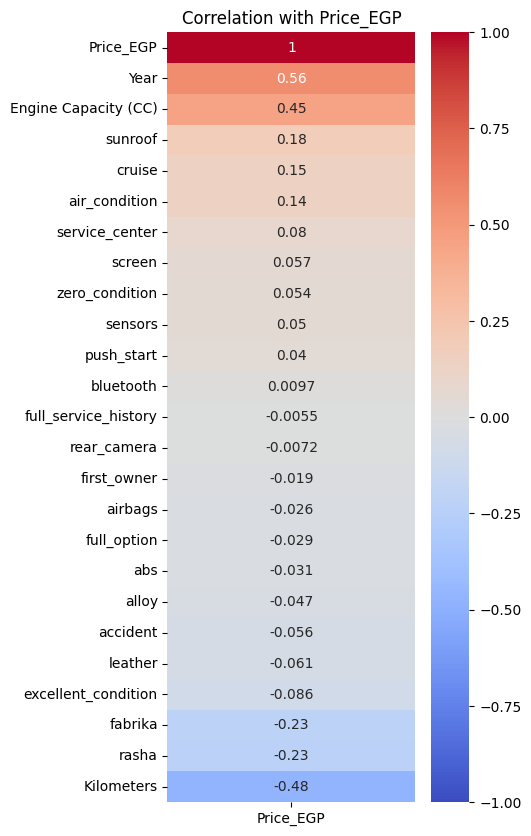

In [48]:
corr = df.select_dtypes(include=[np.number]).corr()
plt.figure(figsize=(4, 10))
sns.heatmap(corr[["Price_EGP"]].sort_values(by="Price_EGP", ascending=False), annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation with Price_EGP")
plt.show()

In [49]:
df.drop(columns=['Description','url'], axis=1, inplace=True)

In [50]:
df.reset_index(drop=True, inplace=True)

In [51]:
df.info()   

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5719 entries, 0 to 5718
Data columns (total 30 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Brand                 5719 non-null   object 
 1   Model                 5719 non-null   object 
 2   Kilometers            5719 non-null   Int64  
 3   Year                  5719 non-null   int64  
 4   Fuel Type             5719 non-null   object 
 5   Transmission Type     5719 non-null   object 
 6   Engine Capacity (CC)  5719 non-null   Int64  
 7   Body Type             5719 non-null   object 
 8   Price_EGP             5719 non-null   float64
 9   fabrika               5719 non-null   int64  
 10  zero_condition        5719 non-null   int64  
 11  rasha                 5719 non-null   int64  
 12  accident              5719 non-null   int64  
 13  excellent_condition   5719 non-null   int64  
 14  service_center        5719 non-null   int64  
 15  full_service_history 

In [52]:
# IQR method to detect outliers for Price_EGP
Q1 = df['Price_EGP'].quantile(0.25)
Q3 = df['Price_EGP'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['Price_EGP'] < lower_bound) | (df['Price_EGP'] > upper_bound)]
outliers

,Brand,Model,Kilometers,Year,Fuel Type,Transmission Type,Engine Capacity (CC),Body Type,Price_EGP,fabrika,...,rear_camera,cruise,alloy,push_start,abs,airbags,air_condition,bluetooth,full_option,first_owner
26,Jaguar,XE,57000,2021,Benzine,Automatic,2000,Sedan,2700000,0,...,0,0,0,0,0,0,1,0,0,0
35,Mercedes-Benz,Other,51000,2022,Benzine,Automatic,3000,Sedan,5500000,0,...,0,0,0,0,0,0,1,0,0,0
54,Mercedes-Benz,GLC 200,50000,2023,Benzine,Automatic,1500,SUV,3625000,0,...,0,0,0,0,0,0,0,0,0,0
62,Mercedes-Benz,GLC 200,33000,2024,Benzine,Automatic,2000,Sports / Coupe,4500000,0,...,0,0,0,0,0,0,0,0,0,0
68,BMW,X3,20000,2024,Benzine,Automatic,2000,4X4,3700000,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5683,Land Rover,Evoque,18000,2022,Benzine,Automatic,2000,4X4,3200000,1,...,0,0,0,0,0,0,0,0,0,0
5690,Mercedes-Benz,GLC 200,3000,2024,Benzine,Automatic,2000,Sedan,4550000,0,...,0,0,0,0,0,0,1,0,0,0
5692,Mercedes-Benz,GLC 300,49500,2024,Benzine,Automatic,3000,SUV,4500000,1,...,0,0,0,0,0,0,0,0,0,0
5704,Audi,Q8,4500,2025,Benzine,Automatic,3000,Hatchback,6800000,0,...,0,0,0,0,0,0,0,0,0,0


In [53]:
df=df[(df['Price_EGP'] >= lower_bound) & (df['Price_EGP'] <= upper_bound)]
df['Price_EGP'].max(),df['Price_EGP'].min(),df['Price_EGP'].mean()

(np.float64(2680000.0), np.float64(100000.0), np.float64(712858.3484021823))

In [54]:
df.duplicated().sum()

np.int64(9)

In [55]:
df.drop_duplicates(inplace=True)

In [56]:
df.to_csv('car_data_cleaned_new.csv', index=False)